# Logistic Regression with Iris Dataset

This notebook demonstrates logistic regression for multi-class classification using the famous Iris dataset.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Explore Iris Dataset

In [2]:
# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['Target'] = y
df['Iris Type'] = df['Target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print("Dataset Shape:", X.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (150, 4)

First few rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target Iris Type  
0       0    Setosa  
1       0    Setosa  
2       0    Setosa  
3       0    Setosa  
4       0    Setosa  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    f

## 3. Data Preprocessing

In [3]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for iris_type, count in zip(['Setosa', 'Versicolor', 'Virginica'], counts):
    print(f"  {iris_type}: {count}")

Training set size: 120
Testing set size: 30

Training set class distribution:
  Setosa: 40
  Versicolor: 40
  Virginica: 40


In [4]:
# Feature scaling (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data (first 5 samples):")
print(X_train_scaled[:5])

Scaled training data (first 5 samples):
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


## 4. Train Logistic Regression Model

In [5]:
# Create and train logistic regression model
# multi_class='multinomial' for multi-class classification
# solver='lbfgs' is suitable for small datasets
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"\nModel parameters:")
print(f"Coefficients shape: {log_reg.coef_.shape}")
print(f"Intercepts: {log_reg.intercept_}")

Model trained successfully!

Model parameters:
Coefficients shape: (3, 4)
Intercepts: [-0.30558672  1.90855554 -1.60296882]


c:\Users\Amazon\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 5. Make Predictions

In [6]:
# Predictions on training and testing sets
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Get prediction probabilities
y_test_proba = log_reg.predict_proba(X_test_scaled)

print("Sample predictions on test set (first 10):")
for i in range(10):
    iris_type = ['Setosa', 'Versicolor', 'Virginica'][y_test_pred[i]]
    actual_type = ['Setosa', 'Versicolor', 'Virginica'][y_test[i]]
    confidence = np.max(y_test_proba[i]) * 100
    print(f"Sample {i+1}: Predicted: {iris_type}, Actual: {actual_type}, Confidence: {confidence:.2f}%")

Sample predictions on test set (first 10):
Sample 1: Predicted: Setosa, Actual: Setosa, Confidence: 97.88%
Sample 2: Predicted: Virginica, Actual: Virginica, Confidence: 62.70%
Sample 3: Predicted: Versicolor, Actual: Versicolor, Confidence: 84.25%
Sample 4: Predicted: Versicolor, Actual: Versicolor, Confidence: 89.46%
Sample 5: Predicted: Setosa, Actual: Setosa, Confidence: 98.85%
Sample 6: Predicted: Versicolor, Actual: Versicolor, Confidence: 67.55%
Sample 7: Predicted: Setosa, Actual: Setosa, Confidence: 99.62%
Sample 8: Predicted: Setosa, Actual: Setosa, Confidence: 94.10%
Sample 9: Predicted: Virginica, Actual: Virginica, Confidence: 85.57%
Sample 10: Predicted: Versicolor, Actual: Versicolor, Confidence: 73.71%


## 6. Model Evaluation

In [7]:
# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Training Accuracy: 0.9583 (95.83%)
Testing Accuracy: 0.9333 (93.33%)


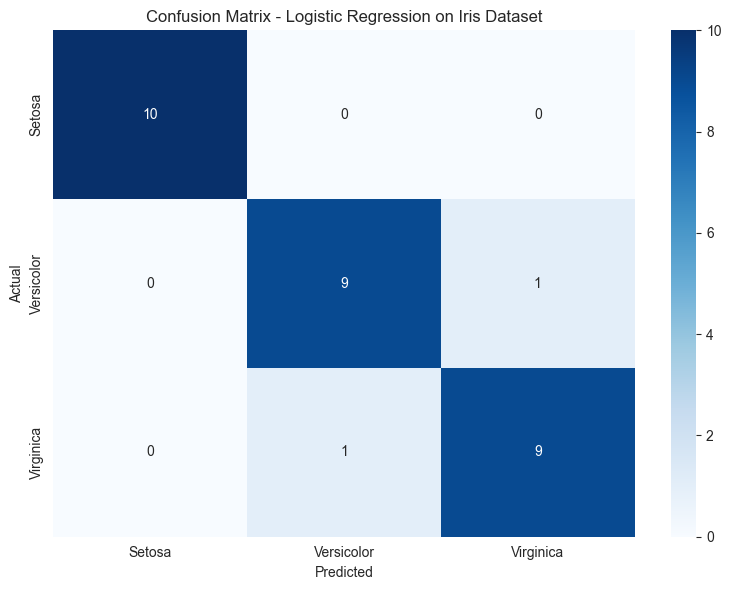

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'])
plt.title('Confusion Matrix - Logistic Regression on Iris Dataset')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [9]:
# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Setosa', 'Versicolor', 'Virginica']))


Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 7. Visualization of Decision Boundaries (2D Projection)

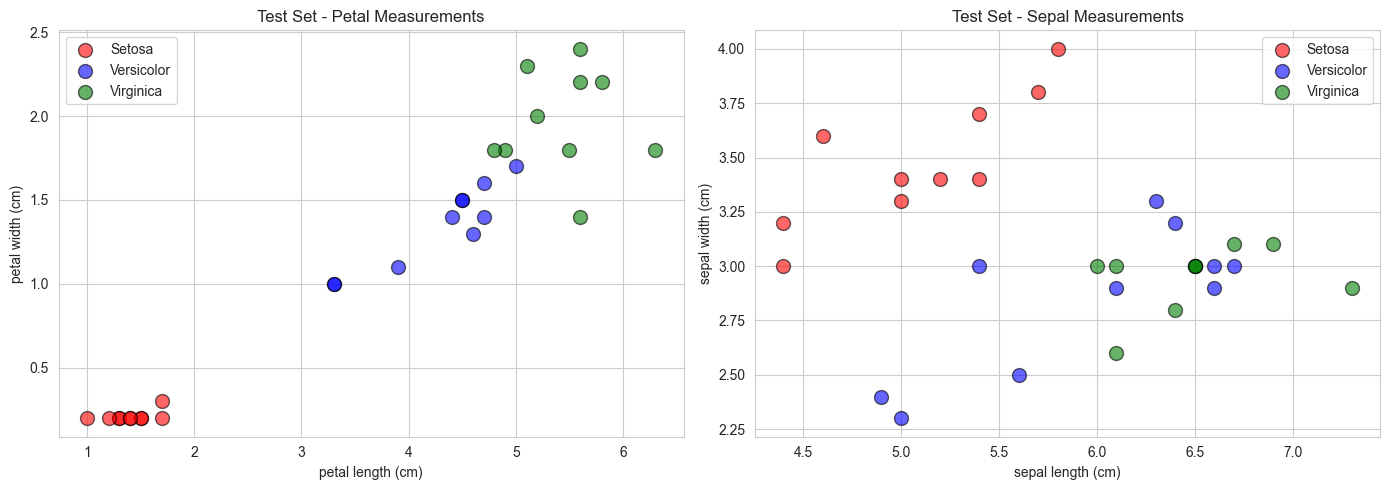

In [10]:
# Create a 2D plot using petal length and petal width
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Petal Length vs Petal Width
feature_1, feature_2 = 2, 3  # Petal Length and Petal Width
colors = ['red', 'blue', 'green']

for i, (color, label) in enumerate(zip(colors, ['Setosa', 'Versicolor', 'Virginica'])):
    indices = y_test == i
    axes[0].scatter(X_test[indices, feature_1], X_test[indices, feature_2], 
                   c=color, label=label, s=100, alpha=0.6, edgecolors='k')

axes[0].set_xlabel(iris.feature_names[feature_1])
axes[0].set_ylabel(iris.feature_names[feature_2])
axes[0].set_title('Test Set - Petal Measurements')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Sepal Length vs Sepal Width
feature_1, feature_2 = 0, 1  # Sepal Length and Sepal Width

for i, (color, label) in enumerate(zip(colors, ['Setosa', 'Versicolor', 'Virginica'])):
    indices = y_test == i
    axes[1].scatter(X_test[indices, feature_1], X_test[indices, feature_2], 
                   c=color, label=label, s=100, alpha=0.6, edgecolors='k')

axes[1].set_xlabel(iris.feature_names[feature_1])
axes[1].set_ylabel(iris.feature_names[feature_2])
axes[1].set_title('Test Set - Sepal Measurements')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Feature Importance (Coefficients)

Model Coefficients:
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
Setosa              -1.088945          1.024208          -1.799056   
Versicolor           0.536337         -0.360487          -0.204074   
Virginica            0.552608         -0.663721           2.003130   

            petal width (cm)  
Setosa             -1.686228  
Versicolor         -0.807957  
Virginica           2.494185  


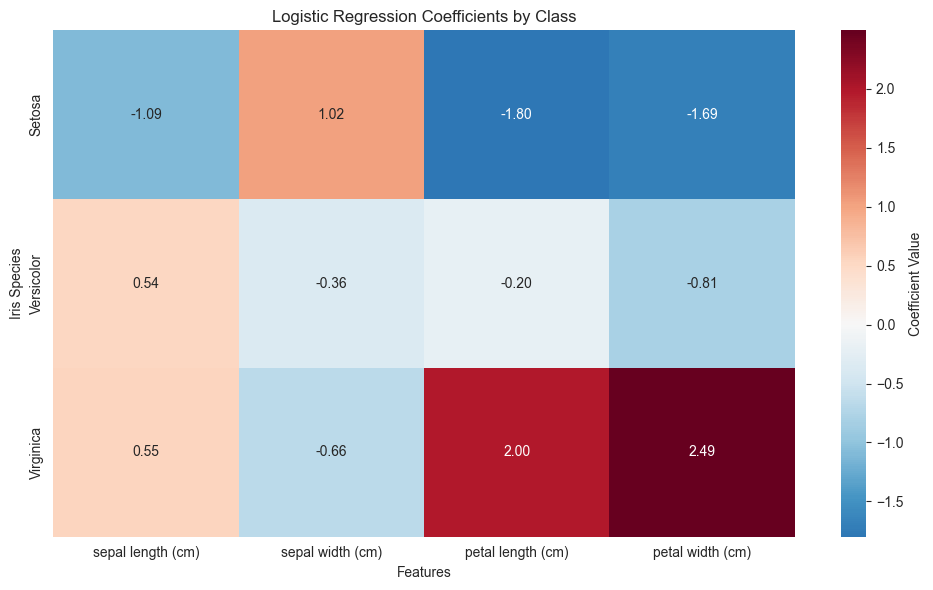

In [11]:
# Visualize the coefficients for each class
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=iris.feature_names,
    index=['Setosa', 'Versicolor', 'Virginica']
)

print("Model Coefficients:")
print(coef_df)

plt.figure(figsize=(10, 6))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Coefficient Value'})
plt.title('Logistic Regression Coefficients by Class')
plt.ylabel('Iris Species')
plt.xlabel('Features')
plt.tight_layout()
plt.show()

## 9. Model Summary

In [12]:
print("="*60)
print("LOGISTIC REGRESSION MODEL SUMMARY")
print("="*60)
print(f"\nDataset: Iris (150 samples, 4 features, 3 classes)")
print(f"\nData Split:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Testing samples: {len(X_test)}")
print(f"\nModel Performance:")
print(f"  - Training Accuracy: {train_accuracy*100:.2f}%")
print(f"  - Testing Accuracy: {test_accuracy*100:.2f}%")
print(f"\nModel Parameters:")
print(f"  - Solver: lbfgs")
print(f"  - Multi-class strategy: multinomial")
print(f"  - Feature scaling: StandardScaler")
print(f"\nKey Insights:")
print(f"  - Most important feature for Setosa: {coef_df.loc['Setosa'].abs().idxmax()}")
print(f"  - Most important feature for Versicolor: {coef_df.loc['Versicolor'].abs().idxmax()}")
print(f"  - Most important feature for Virginica: {coef_df.loc['Virginica'].abs().idxmax()}")
print("="*60)

LOGISTIC REGRESSION MODEL SUMMARY

Dataset: Iris (150 samples, 4 features, 3 classes)

Data Split:
  - Training samples: 120
  - Testing samples: 30

Model Performance:
  - Training Accuracy: 95.83%
  - Testing Accuracy: 93.33%

Model Parameters:
  - Solver: lbfgs
  - Multi-class strategy: multinomial
  - Feature scaling: StandardScaler

Key Insights:
  - Most important feature for Setosa: petal length (cm)
  - Most important feature for Versicolor: petal width (cm)
  - Most important feature for Virginica: petal width (cm)
